# Plus notes on Sanford video

A point to appreciate here is that the problem of the Biblical literalist in accounting for growth of a tiny reproducing population that survived the Great Flood, 4500 years ago, into today's population of 7 billion (see, for instance, Jonathan Safarti's "<a href="https://creation.com/population-growth-since-flood">How Did We Get So Many People in Such a Short Time?</a>" at <a href="https://creation.com/">Creation.com</a>) is complicated by Sanford's thesis that mean fitness has reduced all the while. Sanford has said that Christians must put a "firewall between faith and science" in order for "our science" to have a place in public institutions with "their science" (based on "faith" in materialism) in public institutions (especially science classes in schools). 

"we must put a wall&nbsp;&mdash; a firewall&nbsp;&mdash; between our faith and our science. And we must not let them confuse the two issues."

(CHECK) "it's faith versus faith and science versus science, not faith versus science."

[9:30] "the best selection can do is slow down degeneration."

[4:45] "I would like to suggest that this is the true nature of the conflict: it is faith versus faith, and science versus science."

The "firewall" here, as in *Genetic Entropy*, is absence of explanation of bizarre claims. The assertion of such a high growth rate in human subpopulations makes sense only in the light of religion.

How Evolution Hurts Science (2010)


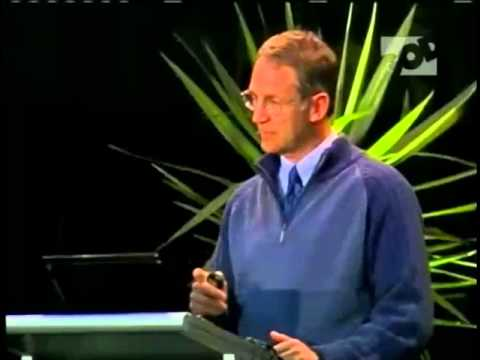

In [1]:
from IPython.lib.display import YouTubeVideo
print('How Evolution Hurts Science (2010)')
YouTubeVideo("P-H4X2b7x7Q", start=4*60+30)

While telling us that Basener and Sanford, like Sanford in *Genetic Entropy* (1st ed., 2005), believe that a high ratio of deleterious to beneficial mutations (nearly neutral most of the time) is inexorably reducing mean fitness. They claim, without citing a source, that high growth rates are "commonly seen" in pre-industrial populations, and offer no explanation of how the growth rates came to be high in the first place. The value of $\exp(0.044) \approx 1.045,$ corresponding to a growth rate of 4.5 percent and a population doubling time of 15.75 years, is not only outrageously high, but also suspiciously similar to the figure of 1.0045 (or 0.45 percent) appearing in various creationist sources. (See, for instance, Jonathan Safarti's "<a href="https://creation.com/population-growth-since-flood">How Did We Get So Many People in Such a Short Time?</a>" at <a href="https://creation.com/">Creation.com</a>.) A parsimonious hypothesis, in light of the various misspellings, grammar errors, and transpositions in the article, is that Basener and Sanford simply lost track of a zero to the right of the decimal point. In any case, it is odd that they relate the annual growth rate to humans, but not the annual death rate of $\exp(0.1) - 1 = 0.105$ (10.5 percent). 

**Numerical checks**

$F(x; 0.5, \beta) = \text{erf}(\sqrt{\beta x})$

In general, numerical accuracy is poor when the left-tail integral of a rapidly decreasing density function is differenced. Need to use the regularized upper incomplete gamma function, i.e., $1 - F(x) = \Gamma(\alpha, \beta x) / \Gamma(\alpha, 0),$ which is equal to $\text{erfc}(\sqrt{\beta x})$ for $\alpha = 0.5.$

Before continuing with the presentation of Basener and Sanford, let us check some of the preceding claims numerically. We start by verifying that calculating the CDF in terms of $\text{erf}$ gives results that are almost identical to those given by the implementation of the Gamma CDF in the Scientific Python (SciPy) statistics package.

In [ ]:
j_minus_i = np.arange(1, 501) # 1, 2, ..., 500
delta = 0.0005                # as in Section 5.4
effects = delta * j_minus_i

alpha, beta = 0.5, 500
gamma = stats.gamma(alpha, scale=1/beta)
f = gamma.pdf
F = gamma.cdf

print('Maximum absolute discrepancy of erf calculation relative to F:',
      maximum_absolute_relative_error(
          erf(np.sqrt(beta * delta * j_minus_i)),
          F(delta * j_minus_i)
      )
)

However, the calculated $F(x)$ reaches 1 at $x \approx 0.0705,$ and we require accurate values for mutation effects of magnitude up to 0.25.

In [ ]:
F_reaches_1_index = np.argmax(F(effects))
F_reaches_1_at_effect = effects[F_reaches_1_index]
F_reaches_1_index, F_reaches_1_at_effect, max(effects)

Thus one does not have to go far into the tail of the distribution for calculated differences of the CDF to be `1 - 1 == 0`. At the time of this writing, the SciPy implementation of $\text{erfc}(x)$ unhelpfully returns `1 - erf(x)`. We will use instead the implementation in the arbitrary-precision <a href="http://mpmath.org/">mpmath</a> library.

In [ ]:
erf_arg = np.sqrt(beta * effects[F_reaches_1_index])
with mp.workdps(16):
    print('16-digit precision: erf =', mp.erf(erf_arg), 'erfc =', mp.erfc(erf_arg))
with mp.workdps(17):
    print('17-digit precision: erf =', mp.erf(erf_arg), 'erfc =', mp.erfc(erf_arg))

This tells us that differencing the CDF in the tail of the Gamma distribution gives a result, in practice, of 1 - 1 = 0. 

In [ ]:
effects = delta * j_minus_i
erf_vector = np.vectorize(mp.erf)
erfc_vector = np.vectorize(mp.erfc)
(erfc_vector(effects) == 1 - erf_vector(effects)).all()

FOO

In [ ]:
def difference(function, x):
    y = function(x)
    return np.abs(y[1:] - y[:-1])

endpoints = delta * (np.arange(0, 501) + 1/2)
erf_endpoints = np.sqrt(beta * endpoints)
cdf_probs = difference(F, endpoints)
sf_probs = difference(stats.gamma(alpha, scale=1/beta).sf, endpoints)
erf_probs = difference(erf, erf_endpoints)
erfc_probs = difference(erfc, erf_endpoints)
mp_erf_probs = difference(erf_vector, erf_endpoints)
mp_erfc_probs = difference(erfc_vector, erf_endpoints)

def plot_discrepancies(data):
    fig, ax = plt.subplots()
    for d, label, ls in data:
        plt.plot(effects, np.abs(d), label=label, ls=ls)
    ax.legend(loc='best')
    ax.set_yscale('log')
    ax.set_ylabel('Absolute Relative Deviation from 100-Digit erfc')
    ax.set_title('NEED')
    return fig, ax

data = [
        [relative_error(erf_probs, mp_erfc_probs), 'ordinary erf', '-'],
        [relative_error(sf_probs, mp_erfc_probs), 'gamma.sf', '-'],
        [relative_error(erfc_probs, mp_erfc_probs), 'ordinary erfc', '-'],
        [relative_error(mp_erf_probs, mp_erfc_probs), 'high-prec erf', '-']
]
data = np.array(data)

fig, ax = plot_discrepancies(data[:-1]);
ax.set_ylim(1e-17, 1e-10)
plt.show()

fig, ax = plot_discrepancies(data[[-1]]);
#ax.set_xlim(0, 0.225);
#ax.set_ylim(1e-100, 1e-75)
plt.show()

In [ ]:
def equation_5_1(x):
    # with precise value in place of 12.6
    return about_12_point_6 * math.exp(-500 * x) * x ** -0.5

def integral(a, b, dps=mp.dps):
    # Integrates density over [a, b] with `dps` digits of precision.
    with mp.workdps(dps):
        return mp.quad(equation_5_1, [a, b])

# Definitions for Section 5.4 experiment
factors = Factors(N_TYPES['Gamma'])
effects = factors.effects
delta = factors.delta

n=150
x = effects[effects > 0][:n]
endpoints = effects[effects >= 0][:n+1] + delta / 2
intervals = [(a, b) for a, b in zip(endpoints[:-1], endpoints[1:])]
integrals = [integral(a, b) for a, b in intervals]


print('Approximately equal to 12.6                      :', about_12_point_6)
#print('Numerical integration of density (high precision):', float(integral(a, b, 100)))
#print('Difference of erfc (ordinary precision)          :', erfc_difference(a, b))
#print('Difference of erf (ordinary precision)           :', erf_difference(a, b))
#integrals = integral(a, b, 100)
print('erfc', convert(relative_error(erfc_probs, integrals), float))
print('erf ', convert(relative_error(erf_probs, integrals), float))